In [1]:
import numpy as np
import healpy as hp
import pickle
from matplotlib.pyplot import *
import matplotlib as mpl
from pylab import cm
# from cmblensplus/wrap/
import curvedsky as cs
# from cmblensplus/utils/
import cmb as CMB
import constant as c
# others
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb
import warnings
warnings.filterwarnings("ignore")

In [2]:
lmin, lmax = 10, 190 

In [3]:
params = local.analysis()

In [4]:
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename()

In [5]:
mask = tools_cmb.prepare_masks(nside=512)
bmap = {}

In [6]:
blm = pickle.load(open(dobj.fLTlm['lbfull'][1],"rb"))
blm['all'][:lmin,:] = 0.
bmap['all'] = cs.utils.hp_alm2map(512,lmax,lmax,blm['all'][:lmax+1,:lmax+1])

In [7]:
# input B-mode map
Qs, Us = hp.read_map(params.ficmb[1],field=(1,2))/c.Tcmb
sBlm = cs.utils.hp_map2alm_spin(hp.get_nside(Qs),lmax,lmax,2,Qs,Us)[1]
sBlm[:lmin,:] = 0.

In [8]:
bmap['inp'] = cs.utils.hp_alm2map(512,lmax,lmax,sBlm)

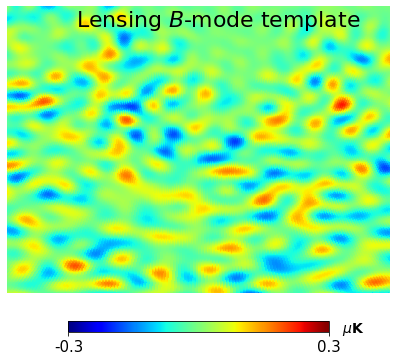

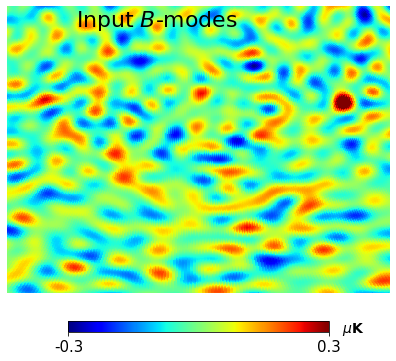

In [15]:
rcParams['xtick.labelsize'] = 15
rcParams["figure.figsize"] = (8,8)
#mpl.rcParams['xtick.major.size'] = 20
for ctype, lab in [('all',r'Lensing $B$-mode template'),('inp',r'Input $B$-modes')]:
    hp.cartview(bmap[ctype]*c.Tcmb,lonra=[-20,20],latra=[-65,-35],min=-3e-1,max=3e-1,unit=r'$\mu$K',title='',cmap=cm.jet)
    figtext(.3,.9,lab,fontsize=22)
    #cbar = colorbar()
    #cbar.tick_params(labelsize=20)
    savefig('fig_bmap_'+ctype+'.pdf',bbox_inches = 'tight', pad_inches = 0.1)